In [99]:
import numpy as np
import math
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Pauli
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Operator, Statevector

np.set_printoptions(precision=6, suppress=True)

# Problem Hamiltonian
# H = 0.7 XX - 0.5 ZY + 0.8 YZ

terms = [
    ( 0.7, "XX"),
    (-0.5, "ZY"),
    ( 0.8, "YZ"),
]

n_system_qubits = 2
n_index_qubits = math.ceil(math.log2(L))
index_dim = 2 ** n_index_qubits
L = len(terms)

alpha = sum(abs(c) for c, _ in terms)

         # because 3 terms need |00>, |01>, |10>
index_dim = 2 ** n_index_qubits

print("Hamiltonian terms:", terms)
print("Number of system qubits:", n_system_qubits)
print("Number of Pauli terms:", L)
print("alpha =", alpha)
print("Index qubits:", n_index_qubits)
print("Index dimension:", index_dim)

Hamiltonian terms: [(0.7, 'XX'), (-0.5, 'ZY'), (0.8, 'YZ')]
Number of system qubits: 2
Number of Pauli terms: 3
alpha = 2.0
Index qubits: 2
Index dimension: 4


In [100]:
theta_candidates = [
    [0.12, 0.73, 0.41, 0.88],
    [0.65, 0.19, 0.94, 0.37],
    [0.08, 0.56, 0.31, 0.79],
    [0.44, 0.22, 0.68, 0.15]]

num_candidates = 4
num_candidate_qubits = 2
num_system_qubits = 2

for k, theta_k in enumerate(theta_candidates):
    print(f"Candidate {k}: {theta_k}")

Candidate 0: [0.12, 0.73, 0.41, 0.88]
Candidate 1: [0.65, 0.19, 0.94, 0.37]
Candidate 2: [0.08, 0.56, 0.31, 0.79]
Candidate 3: [0.44, 0.22, 0.68, 0.15]


In [101]:
# Create the register used to label the candidate configurations.
# For four candidates, two qubits represent:
# |00> -> candidate 0
# |01> -> candidate 1
# |10> -> candidate 2
# |11> -> candidate 3

candidate_register = QuantumRegister(
    num_candidate_qubits,
    name="candidate"
)
# Create a circuit containing only the candidate-index register.
candidate_superposition = QuantumCircuit(
    candidate_register,
    name="CandidateSuperposition"
)
# Applying H to every candidate qubit prepares
#       1/sqrt(N) * sum_k |k>
# For N = 4, this is:
#       1/2 (|00> + |01> + |10> + |11>)
candidate_superposition.h(candidate_register)

print("Candidate-register superposition circuit:")
print(candidate_superposition.draw())

Candidate-register superposition circuit:
             ┌───┐
candidate_0: ┤ H ├
             ├───┤
candidate_1: ┤ H ├
             └───┘


In [102]:
# Simulate the candidate register to verify that all four
# candidate indices have equal amplitudes.
candidate_statevector = Statevector.from_instruction(
    candidate_superposition
)

print("\nCandidate-register statevector:")
print(candidate_statevector)

print("\nCandidate probabilities:")
print(candidate_statevector.probabilities_dict())


Candidate-register statevector:
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))

Candidate probabilities:
{np.str_('00'): np.float64(0.2499999999999999), np.str_('01'): np.float64(0.2499999999999999), np.str_('10'): np.float64(0.2499999999999999), np.str_('11'): np.float64(0.2499999999999999)}


In [103]:
# Step 5: Build the coherent candidate-dependent state loader

def build_candidate_unitary(theta):
    """
    Construct a generic two-qubit unitary U(theta).

    The four input values are used only to produce a distinct working
    state for each candidate. No application-specific interpretation
    is assigned to them in this proof of concept.

    Parameters
    ----------
    theta : sequence of float
        Four numerical parameters associated with one candidate.

    Returns
    -------
    QuantumCircuit
        A two-qubit unitary U(theta).
    """
    if len(theta) != 4:
        raise ValueError(
            f"Expected four parameters, but received {len(theta)}."
        )

    circuit = QuantumCircuit(num_system_qubits)

    # First parameter-dependent rotation layer.
    circuit.ry(theta[0], 0)
    circuit.ry(theta[1], 1)

    # Introduce interaction between the two system qubits.
    circuit.cx(0, 1)

    # Second parameter-dependent rotation layer.
    circuit.ry(theta[2], 0)
    circuit.ry(theta[3], 1)

    return circuit


# Candidate-index register:
#
#   |00> -> candidate 0
#   |01> -> candidate 1
#   |10> -> candidate 2
#   |11> -> candidate 3
candidate_register = QuantumRegister(
    num_candidate_qubits,
    name="candidate"
)

# System register on which the problem Hamiltonian H will act.
system_register = QuantumRegister(
    num_system_qubits,
    name="system"
)

# Combined circuit for coherent candidate-state preparation.
coherent_state_loader = QuantumCircuit(
    candidate_register,
    system_register,
    name="U_load"
)

# Prepare the uniform candidate superposition:
#
#       1/sqrt(N) sum_k |k>
coherent_state_loader.h(candidate_register)

# Apply U(theta_k) to the system register only when the candidate
# register contains the corresponding basis state |k>.
#
# Together, these controlled operations implement:
#
#   U_load = sum_k |k><k| tensor U(theta_k)
for k, theta_k in enumerate(theta_candidates):

    # Construct U(theta_k) for candidate k.
    candidate_unitary = build_candidate_unitary(theta_k)

    # Convert the candidate circuit into a reusable gate.
    candidate_gate = candidate_unitary.to_gate(
        label=f"U_theta_{k}"
    )

    # Add two candidate-register controls.
    #
    # ctrl_state=k means that this gate is activated only on the
    # candidate-register basis state representing integer k.
    controlled_candidate_gate = candidate_gate.control(
        num_ctrl_qubits=num_candidate_qubits,
        ctrl_state=k
    )

    # Controls: candidate register
    # Targets:  system register
    coherent_state_loader.append(
        controlled_candidate_gate,
        [
            *candidate_register,
            *system_register
        ]
    )

print("Coherent candidate-dependent state loader:")
print(coherent_state_loader.draw())

Coherent candidate-dependent state loader:
             ┌───┐                                                        
candidate_0: ┤ H ├──────o─────────────■─────────────o─────────────■───────
             ├───┤      │             │             │             │       
candidate_1: ┤ H ├──────o─────────────o─────────────■─────────────■───────
             └───┘┌─────┴──────┐┌─────┴──────┐┌─────┴──────┐┌─────┴──────┐
   system_0: ─────┤0           ├┤0           ├┤0           ├┤0           ├
                  │  U_theta_0 ││  U_theta_1 ││  U_theta_2 ││  U_theta_3 │
   system_1: ─────┤1           ├┤1           ├┤1           ├┤1           ├
                  └────────────┘└────────────┘└────────────┘└────────────┘


In [104]:
# Simulate the complete candidate-state loading circuit.
coherent_candidate_state = Statevector.from_instruction(
    coherent_state_loader
)

print("Number of qubits:", coherent_state_loader.num_qubits)
print("Statevector dimension:", len(coherent_candidate_state.data))

# Confirm that the complete state remains normalized.
state_norm = np.linalg.norm(coherent_candidate_state.data)

print("Statevector norm:", state_norm)
print("Normalization error:", abs(state_norm - 1.0))

Number of qubits: 4
Statevector dimension: 16
Statevector norm: 0.9999999999999988
Normalization error: 1.2212453270876722e-15


In [105]:
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np

full_state = Statevector.from_instruction(coherent_state_loader)

n_index = num_candidate_qubits
index_dimension = 2**n_index

for k, theta_k in enumerate(theta_candidates):

    # Candidate qubits are the least-significant qubits.
    # Select flat statevector positions:
    # k, k + 2^n_index, k + 2*2^n_index, ...
    extracted_branch = full_state.data[k::index_dimension]

    branch_probability = np.vdot(
        extracted_branch,
        extracted_branch
    ).real

    extracted_state = extracted_branch / np.sqrt(branch_probability)

    reference_circuit = build_candidate_unitary(theta_k)
    reference_state = Statevector.from_instruction(reference_circuit)

    fidelity = state_fidelity(
        Statevector(extracted_state),
        reference_state
    )

    print(f"Candidate k = {k}")
    print(f"  theta_{k} = {theta_k}")
    print(f"  branch probability = {branch_probability:.12f}")
    print(f"  expected probability = {1 / num_candidates:.12f}")
    print(f"  state fidelity = {fidelity:.12f}")
    print()

Candidate k = 0
  theta_0 = [0.12, 0.73, 0.41, 0.88]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000

Candidate k = 1
  theta_1 = [0.65, 0.19, 0.94, 0.37]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000

Candidate k = 2
  theta_2 = [0.08, 0.56, 0.31, 0.79]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000

Candidate k = 3
  theta_3 = [0.44, 0.22, 0.68, 0.15]
  branch probability = 0.250000000000
  expected probability = 0.250000000000
  state fidelity = 1.000000000000



In [106]:
num_hamiltonian_terms = len(terms)
num_hamiltonian_index_qubits = math.ceil(math.log2(num_hamiltonian_terms))
hamiltonian_index_dimension = 2 ** num_hamiltonian_index_qubits

G_vector = np.zeros(hamiltonian_index_dimension, dtype=complex)

for j, (coefficient, _) in enumerate(terms):
    G_vector[j] = np.sqrt(abs(coefficient) / alpha)

PREPARE_G = StatePreparation(G_vector, label="PREPARE_G")
PREPARE_G_DAGGER = PREPARE_G.inverse()

print("Hamiltonian-index qubits:", num_hamiltonian_index_qubits)
print("|G> vector:", G_vector)
print("Norm of |G>:", np.linalg.norm(G_vector))

Hamiltonian-index qubits: 2
|G> vector: [0.591608+0.j 0.5     +0.j 0.632456+0.j 0.      +0.j]
Norm of |G>: 1.0


SELECT circuit built.
SELECT qubits: 4
SELECT depth: 3
SELECT gate count: OrderedDict([('c-unitary_o0', 1), ('c-unitary_o1', 1), ('c-unitary_o2', 1)])


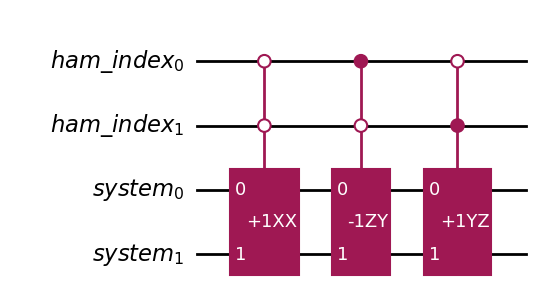

In [107]:
select_index_register = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
select_system_register = QuantumRegister(num_system_qubits, "system")
SELECT = QuantumCircuit(select_index_register, select_system_register, name="SELECT")

for j, (coefficient, pauli_string) in enumerate(terms):
    coefficient_sign = 1.0 if coefficient >= 0 else -1.0
    signed_pauli_matrix = coefficient_sign * Pauli(pauli_string).to_matrix()
    signed_pauli_gate = UnitaryGate(signed_pauli_matrix, label=f"{coefficient_sign:+.0f}{pauli_string}")
    controlled_signed_pauli = signed_pauli_gate.control(num_ctrl_qubits=num_hamiltonian_index_qubits, ctrl_state=j)
    SELECT.append(controlled_signed_pauli, list(select_index_register) + list(select_system_register))

print("SELECT circuit built.")
print("SELECT qubits:", SELECT.num_qubits)
print("SELECT depth:", SELECT.depth())
print("SELECT gate count:", SELECT.count_ops())

SELECT.draw("mpl", fold=-1)

Coherent state preparation built.
Total qubits: 4
Circuit depth: 5
Gate counts: OrderedDict([('h', 2), ('cccircuit-836_o0', 1), ('cccircuit-843_o1', 1), ('cccircuit-850_o2', 1), ('cccircuit-857', 1)])


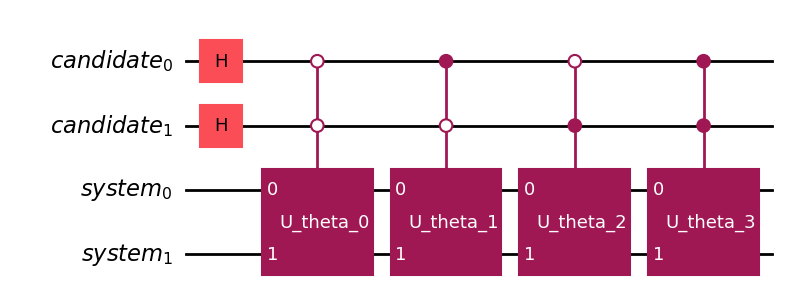

In [108]:
from qiskit import QuantumCircuit, QuantumRegister

# Registers for coherent state preparation
candidate_register = QuantumRegister(
    num_candidate_qubits,
    "candidate"
)

system_register = QuantumRegister(
    num_system_qubits,
    "system"
)

coherent_state_preparation = QuantumCircuit(
    candidate_register,
    system_register,
    name="Coherent_State_Preparation"
)

# Prepare:
#
# (1/2) sum_k |k>|psi(theta_k)>

coherent_state_preparation.compose(
    coherent_state_loader,
    qubits=[
        *candidate_register,
        *system_register
    ],
    inplace=True
)

# coherent_state_preparation.barrier()

print("Coherent state preparation built.")
print("Total qubits:", coherent_state_preparation.num_qubits)
print("Circuit depth:", coherent_state_preparation.depth())
print("Gate counts:", coherent_state_preparation.count_ops())

coherent_state_preparation.draw("mpl", fold=-1)

Probability oracle U_p built.
Total qubits: 5
Circuit depth: 3
Gate counts: OrderedDict([('h', 2), ('state_preparation', 1), ('cSELECT', 1), ('state_preparation_dg', 1)])


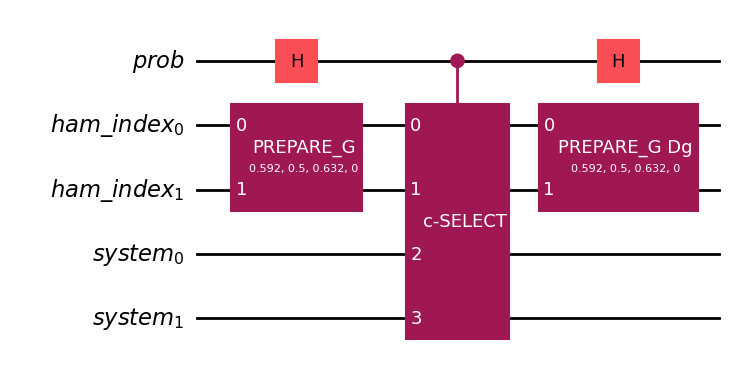

In [109]:
from qiskit import QuantumCircuit, QuantumRegister

# Registers for U_p
probability_ancilla = QuantumRegister(
    1,
    "prob"
)

hamiltonian_index_register = QuantumRegister(
    num_hamiltonian_index_qubits,
    "ham_index"
)

system_register = QuantumRegister(
    num_system_qubits,
    "system"
)

U_p = QuantumCircuit(
    probability_ancilla,
    hamiltonian_index_register,
    system_register,
    name="U_p"
)

# 1. Hadamard-test ancilla

U_p.h(probability_ancilla[0])

# 2. Prepare the Hamiltonian coefficient state |G>

U_p.append(
    PREPARE_G,
    list(hamiltonian_index_register)
)

# 3. Apply SELECT only when the probability ancilla is |1>

controlled_SELECT = SELECT.to_gate(
    label="c-SELECT"
).control(1)

U_p.append(
    controlled_SELECT,
    [
        probability_ancilla[0],
        *hamiltonian_index_register,
        *system_register
    ]
)

# 4. Unprepare the Hamiltonian-index register

U_p.append(
    PREPARE_G_DAGGER,
    list(hamiltonian_index_register)
)

# 5. Final Hadamard on the probability ancilla

U_p.h(probability_ancilla[0])

# U_p.barrier()

print("Probability oracle U_p built.")
print("Total qubits:", U_p.num_qubits)
print("Circuit depth:", U_p.depth())
print("Gate counts:", U_p.count_ops())

U_p.draw("mpl", fold=-1)

Complete coherent probability test built.
Total qubits: 7
Circuit depth: 7
Gate counts: OrderedDict([('h', 4), ('cccircuit-836_o0', 1), ('cccircuit-843_o1', 1), ('cccircuit-850_o2', 1), ('cccircuit-857', 1), ('state_preparation', 1), ('cSELECT', 1), ('state_preparation_dg', 1)])


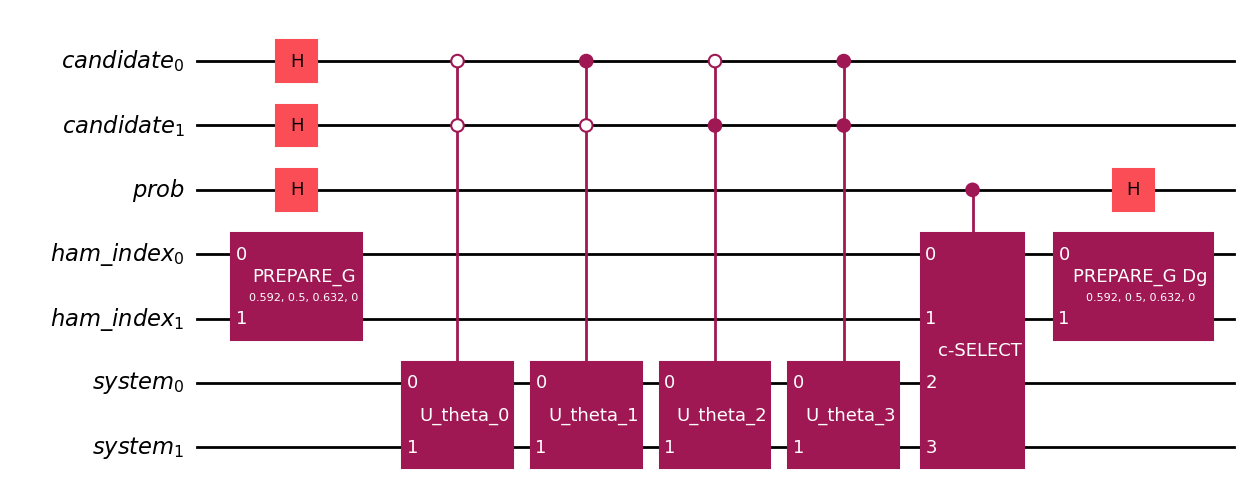

In [110]:
from qiskit import QuantumCircuit, QuantumRegister

# Registers for the complete coherent test
candidate_register = QuantumRegister(num_candidate_qubits,"candidate")

probability_ancilla = QuantumRegister(1, "prob")

hamiltonian_index_register = QuantumRegister( num_hamiltonian_index_qubits, "ham_index")

system_register = QuantumRegister(num_system_qubits, "system")

coherent_probability_oracle = QuantumCircuit(
    candidate_register, probability_ancilla, hamiltonian_index_register, system_register, name="coherent_probability_oracle")

# 1. Prepare:
# (1/2) sum_k |k>|psi(theta_k)>
coherent_probability_oracle.compose(coherent_state_preparation, qubits=[*candidate_register,*system_register],inplace=True)

# 2. Apply U_p
# U_p acts only on:
# probability ancilla + Hamiltonian index + system
coherent_probability_oracle.compose(U_p,qubits=[probability_ancilla[0], *hamiltonian_index_register, *system_register], inplace=True)

# coherent_probability_oracle.barrier()

print("Complete coherent probability test built.")
print("Total qubits:", coherent_probability_oracle.num_qubits)
print("Circuit depth:", coherent_probability_oracle.depth())
print("Gate counts:", coherent_probability_oracle.count_ops())

coherent_probability_oracle.draw("mpl", fold=-1)

In [111]:
U_load_gate = coherent_state_preparation.to_gate(label="U_load_gate")
U_P_gate = U_p.to_gate(label="U_P_gate")

Full probability oracle built.
Total qubits: 7
Depth: 2
Gate counts: OrderedDict([('Coherent_State_Preparation', 1), ('U_p', 1)])


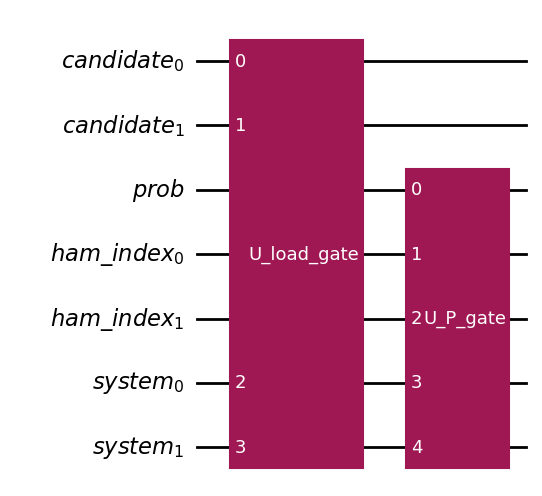

In [112]:
candidate_register = QuantumRegister(num_candidate_qubits, "candidate")
probability_register = QuantumRegister(1, "prob")
hamiltonian_index_register = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
system_register = QuantumRegister(num_system_qubits, "system")

U_prob_full = QuantumCircuit(candidate_register, probability_register, hamiltonian_index_register, system_register, name="U_prob_full")

U_prob_full.append(U_load_gate, list(candidate_register) + list(system_register))
U_prob_full.append(U_P_gate, list(probability_register) + list(hamiltonian_index_register) + list(system_register))

U_prob_full_gate = U_prob_full.to_gate(label="U_prob_full")
U_prob_full_dagger_gate = U_prob_full_gate.inverse()

print("Full probability oracle built.")
print("Total qubits:", U_prob_full.num_qubits)
print("Depth:", U_prob_full.depth())
print("Gate counts:", U_prob_full.count_ops())

U_prob_full.draw("mpl", fold=-1)

Grover operator built.
Total qubits: 7
Depth: 4
Gate counts: OrderedDict([('U_prob_full', 1), ('R_Pi2', 1), ('U_prob_full_dg', 1), ('R_Pi1', 1)])


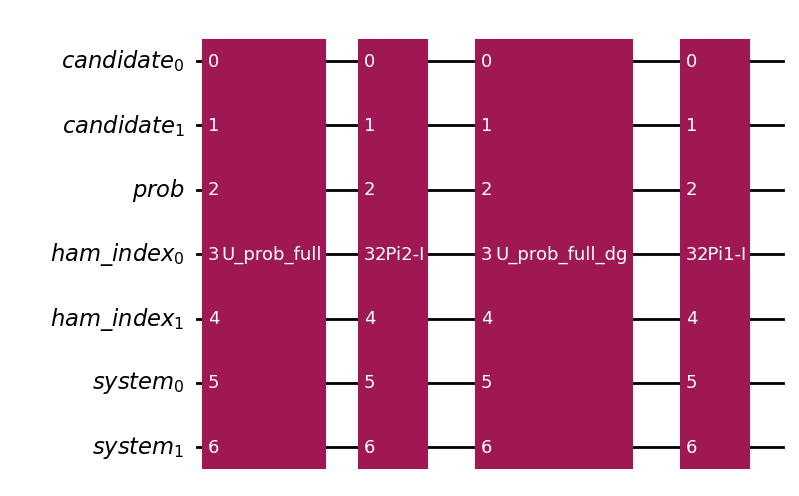

In [113]:
candidate = QuantumRegister(num_candidate_qubits, "candidate")
prob = QuantumRegister(1, "prob")
ham_index = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
system = QuantumRegister(num_system_qubits, "system")

aux_qubits = [prob[0], *ham_index, *system]

R_Pi1 = QuantumCircuit(candidate, prob, ham_index, system, name="R_Pi1")
R_Pi1.x(aux_qubits)
R_Pi1.h(aux_qubits[-1])
R_Pi1.mcx(aux_qubits[:-1], aux_qubits[-1])
R_Pi1.h(aux_qubits[-1])
R_Pi1.x(aux_qubits)
R_Pi1.global_phase += np.pi
R_Pi1_gate = R_Pi1.to_gate(label="2Pi1-I")

R_Pi2 = QuantumCircuit(candidate, prob, ham_index, system, name="R_Pi2")
R_Pi2.z(prob[0])
R_Pi2.global_phase += np.pi
R_Pi2_gate = R_Pi2.to_gate(label="2Pi2-I")

G_U = QuantumCircuit(candidate, prob, ham_index, system, name="G_U")
all_qubits = [*candidate, prob[0], *ham_index, *system]

G_U.append(U_prob_full_gate, all_qubits)
G_U.append(R_Pi2_gate, all_qubits)
G_U.append(U_prob_full_dagger_gate, all_qubits)
G_U.append(R_Pi1_gate, all_qubits)

G_U_gate = G_U.to_gate(label="G_U")
G_U_dagger_gate = G_U_gate.inverse()

print("Grover operator built.")
print("Total qubits:", G_U.num_qubits)
print("Depth:", G_U.depth())
print("Gate counts:", G_U.count_ops())

G_U.draw("mpl", fold=-1)

### Grover Reflections

The auxiliary register contains prob, ham_index, and system.

$
\Pi_1=I_{\text{candidate}}\otimes|0\cdots0\rangle\langle0\cdots0|_{\text{aux}}
$

so $2\Pi_1-I$ reflects about all auxiliary qubits being zero.

$
\Pi_2=I_{\text{candidate}}\otimes I\otimes|1\rangle\langle1|_{\text{prob}}
$

so $2\Pi_2-I$ reflects only the subspace where the probability qubit is $|1\rangle$.

The candidate register is unchanged by both reflections.

In [ ]:
epsilon_0 = 0.05

M_bound = 2 * np.log(1 / epsilon_0) / np.log(np.log(1 / epsilon_0))
M = max(1, math.ceil(M_bound))

power_labels = list(range(-M, M + 1))
beta = {}

for m in power_labels:
    beta_m = 0.0j
    for K in range(abs(m), M + 1):
        beta_m += math.comb(2 * K, K - m) * ((-1) ** m) * (1j ** K) / (math.factorial(K) * 2 ** (2 * K))
    beta[m] = beta_m

lambda_beta = sum(abs(beta[m]) for m in power_labels)

print("epsilon_0 =", epsilon_0)
print("M bound =", M_bound)
print("M =", M)
print("beta coefficients:")

for m in power_labels:
    print(f"m={m:3d}: beta={beta[m]}, |beta|={abs(beta[m]):.12f}")

print("lambda_beta =", lambda_beta)

epsilon_0 = 0.05
M bound = 5.460742117664072
M = 6
beta coefficients:
m= -6: beta=(-3.390842013888889e-07+0j), |beta|=0.000000339084
m= -5: beta=(4.069010416666667e-06-8.138020833333333e-06j), |beta|=0.000009098584
m= -4: beta=(0.000140380859375+8.138020833333333e-05j), |beta|=0.000162263748
m= -3: beta=(-0.0012274848090277778+0.0022379557291666665j), |beta|=0.002552482087
m= -2: beta=(-0.026860555013020832-0.0146484375j), |beta|=0.030595197937
m= -1: beta=(0.11615397135416668-0.212646484375j), |beta|=0.242302027186
m=  0: beta=(0.8235799153645833+0.4499674479166667j), |beta|=0.938485258902
m=  1: beta=(0.11615397135416668-0.212646484375j), |beta|=0.242302027186
m=  2: beta=(-0.026860555013020832-0.0146484375j), |beta|=0.030595197937
m=  3: beta=(-0.0012274848090277778+0.0022379557291666665j), |beta|=0.002552482087
m=  4: beta=(0.000140380859375+8.138020833333333e-05j), |beta|=0.000162263748
m=  5: beta=(4.069010416666667e-06-8.138020833333333e-06j), |beta|=0.000009098584
m=  6: beta=(

### Taylor Truncation and $\beta_m$ Coefficients

Theorem 14 approximates the target phase operator as

$
e^{ip}I \approx \sum_{m=-M}^{M}\beta_m G_U^m.
$

The code first chooses a truncation order $M$ from the target error $\epsilon_0$:

$
M \geq \frac{2\ln(1/\epsilon_0)}{\ln\ln(1/\epsilon_0)}.
$

A smaller $\epsilon_0$ requires a larger $M$, so more Taylor terms and more Grover powers are included. The value is rounded up because $M$ must be an integer.

For every Grover power $m\in\{-M,\ldots,M\}$, the code computes

$
\beta_m=
\sum_{K=|m|}^{M}
\binom{2K}{K-m}
\frac{(-1)^m i^K}{K!\,2^{2K}}.
$

Here, $K$ is the Taylor-series order and $m$ labels the power $G_U^m$. Each Taylor order contributes to several Grover powers. The code collects all contributions belonging to the same power $m$ into one coefficient $\beta_m$.

Finally,

$
\lambda_\beta=\sum_{m=-M}^{M}|\beta_m|
$

is computed for normalizing the later LCU state-preparation circuit.

In [117]:
num_power_terms = len(power_labels)
num_power_qubits = math.ceil(math.log2(num_power_terms))
power_dimension = 2 ** num_power_qubits

right_amplitudes = np.zeros(power_dimension, dtype=complex)
left_amplitudes = np.zeros(power_dimension, dtype=complex)

for index, m in enumerate(power_labels):
    magnitude = np.sqrt(abs(beta[m]) / lambda_beta)
    phase = np.angle(beta[m])
    right_amplitudes[index] = magnitude
    left_amplitudes[index] = magnitude * np.exp(-1j * phase)

PREPARE_beta_right = StatePreparation(right_amplitudes, label="PREPARE_beta_R")
PREPARE_beta_left = StatePreparation(left_amplitudes, label="PREPARE_beta_L")
PREPARE_beta_left_dagger = PREPARE_beta_left.inverse()

print("number of powers =", num_power_terms)
print("power qubits =", num_power_qubits)
print("power dimension =", power_dimension)
print("right norm =", np.linalg.norm(right_amplitudes))
print("left norm =", np.linalg.norm(left_amplitudes))

for index, m in enumerate(power_labels):
    reconstructed_beta = np.conj(left_amplitudes[index]) * right_amplitudes[index]
    print(f"m={m:3d}: expected={beta[m] / lambda_beta}, reconstructed={reconstructed_beta}")

number of powers = 13
power qubits = 4
power dimension = 16
right norm = 0.9999999999999999
left norm = 1.0
m= -6: expected=(-2.2761482905284573e-07+0j), reconstructed=(-2.2761482905284573e-07+2.787477718380395e-23j)
m= -5: expected=(2.7313779486341484e-06-5.462755897268297e-06j), reconstructed=(2.7313779486341497e-06-5.462755897268298e-06j)
m= -4: expected=(9.423253922787812e-05+5.462755897268297e-05j), reconstructed=(9.42325392278781e-05+5.4627558972682964e-05j)
m= -3: expected=(-0.0008239656811713015+0.0015022578717487816j), reconstructed=(-0.0008239656811713017+0.0015022578717487813j)
m= -2: expected=(-0.01803050868342117-0.009832960615082934j), reconstructed=(-0.01803050868342117-0.009832960615082938j)
m= -1: expected=(0.07796991492171042-0.1427418115956206j), reconstructed=(0.07796991492171043-0.1427418115956206j)
m=  0: expected=(0.5528390909373976+0.3020466990717587j), reconstructed=(0.5528390909373974+0.3020466990717587j)
m=  1: expected=(0.07796991492171042-0.1427418115956206

In [127]:
# power_register = QuantumRegister(num_power_qubits, "power")
# candidate_register = QuantumRegister(num_candidate_qubits, "candidate")
# probability_register = QuantumRegister(1, "prob")
# hamiltonian_index_register = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
# system_register = QuantumRegister(num_system_qubits, "system")

# SELECT_G = QuantumCircuit(power_register, candidate_register, probability_register, hamiltonian_index_register, system_register, name="SELECT_G")

# work_qubits = [*candidate_register, probability_register[0], *hamiltonian_index_register, *system_register]

# for index, m in enumerate(power_labels):
#     if m == 0:
#         continue
#     if m > 0:
#         G_power_gate = G_U_gate.power(m)
#     else:
#         G_power_gate = G_U_dagger_gate.power(abs(m))

#     controlled_G_power = G_power_gate.control(num_ctrl_qubits=num_power_qubits, ctrl_state=index)
#     SELECT_G.append(controlled_G_power, list(power_register) + work_qubits)

# SELECT_G_gate = SELECT_G.to_gate(label="SELECT_G")

# print("SELECT_G built.")
# print("number of power qubits =", num_power_qubits)
# print("number of work qubits =", len(work_qubits))
# print("total qubits =", SELECT_G.num_qubits)
# print("depth =", SELECT_G.depth())
# print("gate counts =", SELECT_G.count_ops())

# SELECT_G.draw("mpl", fold=-1)

Once done, push commit as 'implementation of taylors series as in quantum optimization algos paper - arXiv:1711.00465v3'

testing with m=3

In [140]:
epsilon_0 = 0.05

# M_bound = 2 * np.log(1 / epsilon_0) / np.log(np.log(1 / epsilon_0))
# M = max(1, math.ceil(M_bound))
######## setting M = 3 for testing 
M=6

power_labels = list(range(-M, M + 1))
beta = {}

for m in power_labels:
    beta_m = 0.0j
    for K in range(abs(m), M + 1):
        beta_m += math.comb(2 * K, K - m) * ((-1) ** m) * (1j ** K) / (math.factorial(K) * 2 ** (2 * K))
    beta[m] = beta_m

lambda_beta = sum(abs(beta[m]) for m in power_labels)

print("epsilon_0 =", epsilon_0)
print("M bound =", M_bound)
print("M =", M)
print("beta coefficients:")

for m in power_labels:
    print(f"m={m:3d}: beta={beta[m]}, |beta|={abs(beta[m]):.12f}")

print("lambda_beta =", lambda_beta)

epsilon_0 = 0.05
M bound = 5.460742117664072
M = 6
beta coefficients:
m= -6: beta=(-3.390842013888889e-07+0j), |beta|=0.000000339084
m= -5: beta=(4.069010416666667e-06-8.138020833333333e-06j), |beta|=0.000009098584
m= -4: beta=(0.000140380859375+8.138020833333333e-05j), |beta|=0.000162263748
m= -3: beta=(-0.0012274848090277778+0.0022379557291666665j), |beta|=0.002552482087
m= -2: beta=(-0.026860555013020832-0.0146484375j), |beta|=0.030595197937
m= -1: beta=(0.11615397135416668-0.212646484375j), |beta|=0.242302027186
m=  0: beta=(0.8235799153645833+0.4499674479166667j), |beta|=0.938485258902
m=  1: beta=(0.11615397135416668-0.212646484375j), |beta|=0.242302027186
m=  2: beta=(-0.026860555013020832-0.0146484375j), |beta|=0.030595197937
m=  3: beta=(-0.0012274848090277778+0.0022379557291666665j), |beta|=0.002552482087
m=  4: beta=(0.000140380859375+8.138020833333333e-05j), |beta|=0.000162263748
m=  5: beta=(4.069010416666667e-06-8.138020833333333e-06j), |beta|=0.000009098584
m=  6: beta=(

In [ ]:
num_power_terms = len(power_labels)
num_power_qubits = math.ceil(math.log2(num_power_terms))
power_dimension = 2 ** num_power_qubits

right_amplitudes = np.zeros(power_dimension, dtype=complex)
left_amplitudes = np.zeros(power_dimension, dtype=complex)

for index, m in enumerate(power_labels):
    magnitude = np.sqrt(abs(beta[m]) / lambda_beta)
    phase = np.angle(beta[m])
    right_amplitudes[index] = magnitude
    left_amplitudes[index] = magnitude * np.exp(-1j * phase)

PREPARE_beta_right = StatePreparation(right_amplitudes, label="PREPARE_beta_R")
PREPARE_beta_left = StatePreparation(left_amplitudes, label="PREPARE_beta_L")
PREPARE_beta_left_dagger = PREPARE_beta_left.inverse()

print("number of powers =", num_power_terms)
print("power qubits =", num_power_qubits)
print("power dimension =", power_dimension)
print("right norm =", np.linalg.norm(right_amplitudes))
print("left norm =", np.linalg.norm(left_amplitudes))

for index, m in enumerate(power_labels):
    reconstructed_beta = np.conj(left_amplitudes[index]) * right_amplitudes[index]
    print(f"m={m:3d}: expected={beta[m] / lambda_beta}, reconstructed={reconstructed_beta}")

number of powers = 13
power qubits = 4
power dimension = 16
right norm = 0.9999999999999999
left norm = 1.0
m= -6: expected=(-2.2761482905284573e-07+0j), reconstructed=(-2.2761482905284573e-07+2.787477718380395e-23j)
m= -5: expected=(2.7313779486341484e-06-5.462755897268297e-06j), reconstructed=(2.7313779486341497e-06-5.462755897268298e-06j)
m= -4: expected=(9.423253922787812e-05+5.462755897268297e-05j), reconstructed=(9.42325392278781e-05+5.4627558972682964e-05j)
m= -3: expected=(-0.0008239656811713015+0.0015022578717487816j), reconstructed=(-0.0008239656811713017+0.0015022578717487813j)
m= -2: expected=(-0.01803050868342117-0.009832960615082934j), reconstructed=(-0.01803050868342117-0.009832960615082938j)
m= -1: expected=(0.07796991492171042-0.1427418115956206j), reconstructed=(0.07796991492171043-0.1427418115956206j)
m=  0: expected=(0.5528390909373976+0.3020466990717587j), reconstructed=(0.5528390909373974+0.3020466990717587j)
m=  1: expected=(0.07796991492171042-0.1427418115956206

In [142]:
# power_register = QuantumRegister(num_power_qubits, "power")
# candidate_register = QuantumRegister(num_candidate_qubits, "candidate")
# probability_register = QuantumRegister(1, "prob")
# hamiltonian_index_register = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
# system_register = QuantumRegister(num_system_qubits, "system")

# SELECT_G = QuantumCircuit(power_register, candidate_register, probability_register, hamiltonian_index_register, system_register, name="SELECT_G")

# work_qubits = [*candidate_register, probability_register[0], *hamiltonian_index_register, *system_register]

# for index, m in enumerate(power_labels):
#     if m == 0:
#         continue
#     if m > 0:
#         G_power_gate = G_U_gate.power(m)
#     else:
#         G_power_gate = G_U_dagger_gate.power(abs(m))

#     controlled_G_power = G_power_gate.control(num_ctrl_qubits=num_power_qubits, ctrl_state=index)
#     SELECT_G.append(controlled_G_power, list(power_register) + work_qubits)

# SELECT_G_gate = SELECT_G.to_gate(label="SELECT_G")

# print("SELECT_G built.")
# print("number of power qubits =", num_power_qubits)
# print("number of work qubits =", len(work_qubits))
# print("total qubits =", SELECT_G.num_qubits)
# print("depth =", SELECT_G.depth())
# print("gate counts =", SELECT_G.count_ops())

# SELECT_G.draw("mpl", fold=-1)

select from standalone version. 

In [ ]:
power_register = QuantumRegister(num_power_qubits, "power")
candidate_register = QuantumRegister(num_candidate_qubits, "candidate")
probability_register = QuantumRegister(1, "prob")
hamiltonian_index_register = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
system_register = QuantumRegister(num_system_qubits, "system")

SELECT_G = QuantumCircuit(power_register, candidate_register, probability_register, hamiltonian_index_register, system_register, name="SELECT_G")

work_qubits = [*candidate_register, probability_register[0], *hamiltonian_index_register, *system_register]
controlled_G = G_U_gate.control(num_power_qubits)
controlled_G_dagger = G_U_dagger_gate.control(num_power_qubits)

for encoded_state, m in enumerate(power_labels):
    if m == 0:
        continue

    bitstring = format(encoded_state, f"0{num_power_qubits}b")[::-1]

    for qubit, bit in zip(power_register, bitstring):
        if bit == "0":
            SELECT_G.x(qubit)

    selected_gate = controlled_G if m > 0 else controlled_G_dagger

    for _ in range(abs(m)):
        SELECT_G.append(selected_gate, list(power_register) + work_qubits)

    for qubit, bit in zip(power_register, bitstring):
        if bit == "0":
            SELECT_G.x(qubit)

SELECT_G_gate = SELECT_G.to_gate(label="SELECT_G")

print("SELECT_G built.")
print("number of power qubits =", num_power_qubits)
print("number of work qubits =", len(work_qubits))
print("total qubits =", SELECT_G.num_qubits)
print("depth =", SELECT_G.depth())
print("gate counts =", SELECT_G.count_ops())

SELECT_G built.
number of power qubits = 4
number of work qubits = 7
total qubits = 11
depth = 64
gate counts = OrderedDict([('x', 56), ('c4G_U_dg', 21), ('c4G_U', 21)])


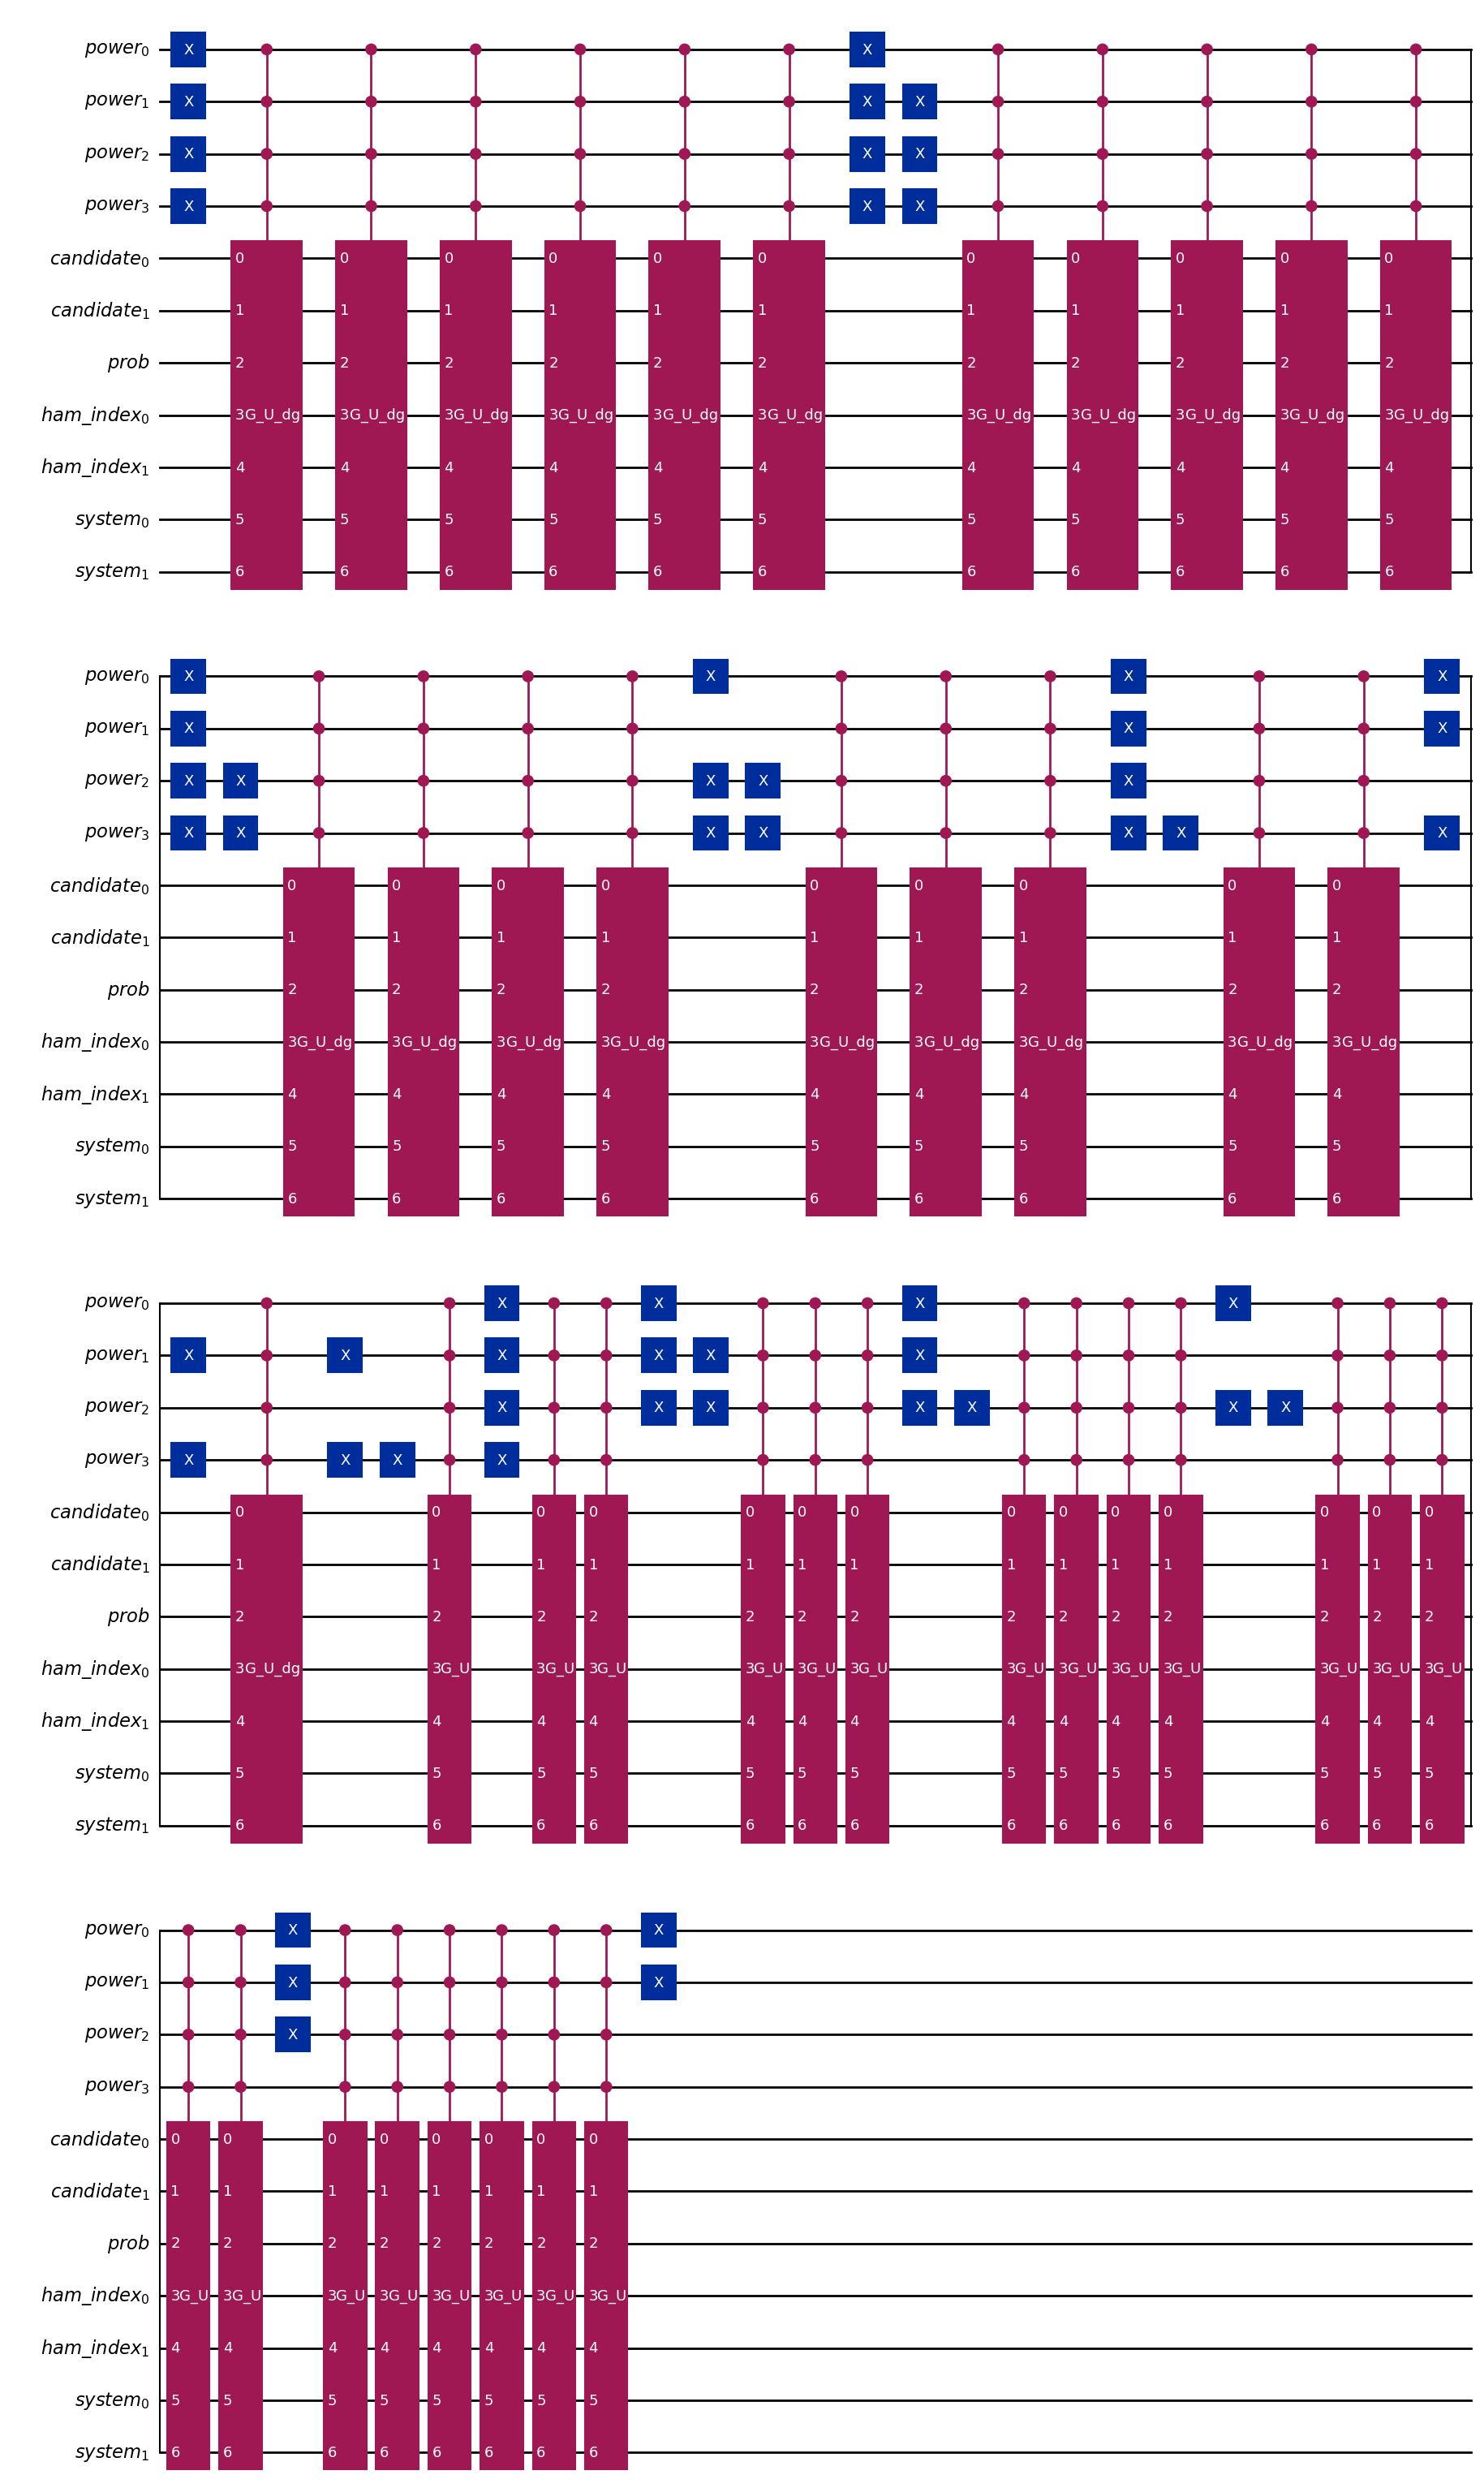

In [144]:
SELECT_G.draw("mpl")

changed bitstring setup

In [146]:
num_power_terms = len(power_labels)
num_power_qubits = math.ceil(math.log2(num_power_terms))
power_dimension = 2 ** num_power_qubits

right_amplitudes = np.zeros(power_dimension, dtype=complex)
left_amplitudes = np.zeros(power_dimension, dtype=complex)
power_bitstrings = {}

for encoded_state, m in enumerate(power_labels):
    bitstring = format(encoded_state, f"0{num_power_qubits}b")
    qiskit_index = int(bitstring[::-1], 2)
    magnitude = np.sqrt(abs(beta[m]) / lambda_beta)
    phase = np.angle(beta[m])
    power_bitstrings[m] = bitstring
    right_amplitudes[qiskit_index] = magnitude
    left_amplitudes[qiskit_index] = magnitude * np.exp(-1j * phase)

PREPARE_beta_right = StatePreparation(right_amplitudes, label="PREPARE_beta_R")
PREPARE_beta_left = StatePreparation(left_amplitudes, label="PREPARE_beta_L")
PREPARE_beta_left_dagger = PREPARE_beta_left.inverse()

print("power mapping:")
for m in power_labels:
    print(f"m={m:3d}: |{power_bitstrings[m]}>")

power mapping:
m= -6: |0000>
m= -5: |0001>
m= -4: |0010>
m= -3: |0011>
m= -2: |0100>
m= -1: |0101>
m=  0: |0110>
m=  1: |0111>
m=  2: |1000>
m=  3: |1001>
m=  4: |1010>
m=  5: |1011>
m=  6: |1100>


SELECT_G built.
number of power qubits = 4
number of work qubits = 7
total qubits = 11
depth = 56
gate counts = OrderedDict([('x', 28), ('c4G_U_dg', 21), ('c4G_U', 21)])


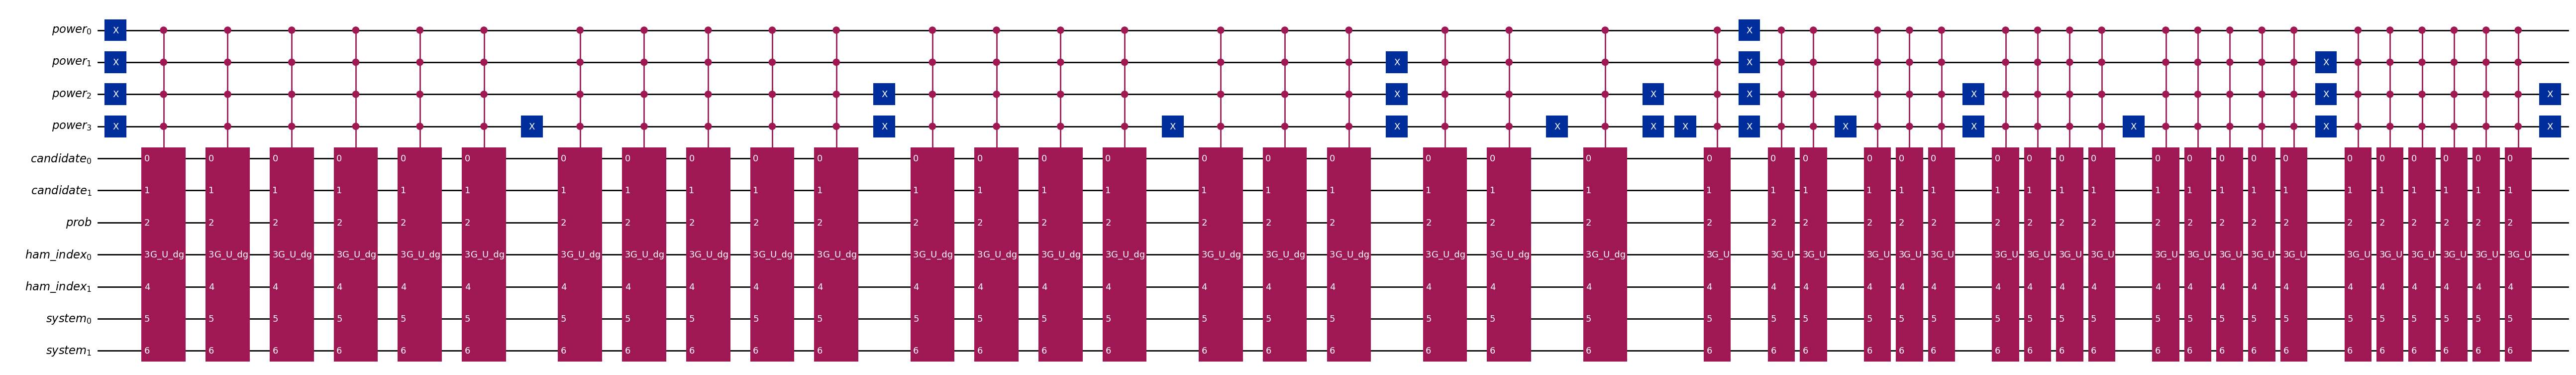

In [ ]:
power_register = QuantumRegister(num_power_qubits, "power")
candidate_register = QuantumRegister(num_candidate_qubits, "candidate")
probability_register = QuantumRegister(1, "prob")
hamiltonian_index_register = QuantumRegister(num_hamiltonian_index_qubits, "ham_index")
system_register = QuantumRegister(num_system_qubits, "system")

SELECT_G = QuantumCircuit(power_register, candidate_register, probability_register, hamiltonian_index_register, system_register, name="SELECT_G")

work_qubits = [*candidate_register, probability_register[0], *hamiltonian_index_register, *system_register]
controlled_G = G_U_gate.control(num_power_qubits)
controlled_G_dagger = G_U_dagger_gate.control(num_power_qubits)

current_mask = [0] * num_power_qubits

for encoded_state, m in enumerate(power_labels):
    target_bits = [int(bit) for bit in format(encoded_state, f"0{num_power_qubits}b")]
    required_mask = [1 - bit for bit in target_bits]

    for wire_index in range(num_power_qubits):
        if current_mask[wire_index] != required_mask[wire_index]:
            SELECT_G.x(power_register[wire_index])

    current_mask = required_mask

    if m > 0:
        for _ in range(m):
            SELECT_G.append(controlled_G, list(power_register) + work_qubits)
    elif m < 0:
        for _ in range(abs(m)):
            SELECT_G.append(controlled_G_dagger, list(power_register) + work_qubits)

for wire_index in range(num_power_qubits):
    if current_mask[wire_index] == 1:
        SELECT_G.x(power_register[wire_index])

SELECT_G_gate = SELECT_G.to_gate(label="SELECT_G")

print("SELECT_G built.")
print("number of power qubits =", num_power_qubits)
print("number of work qubits =", len(work_qubits))
print("total qubits =", SELECT_G.num_qubits)
print("depth =", SELECT_G.depth())
print("gate counts =", SELECT_G.count_ops())

SELECT_G.draw("mpl", fold=-1)

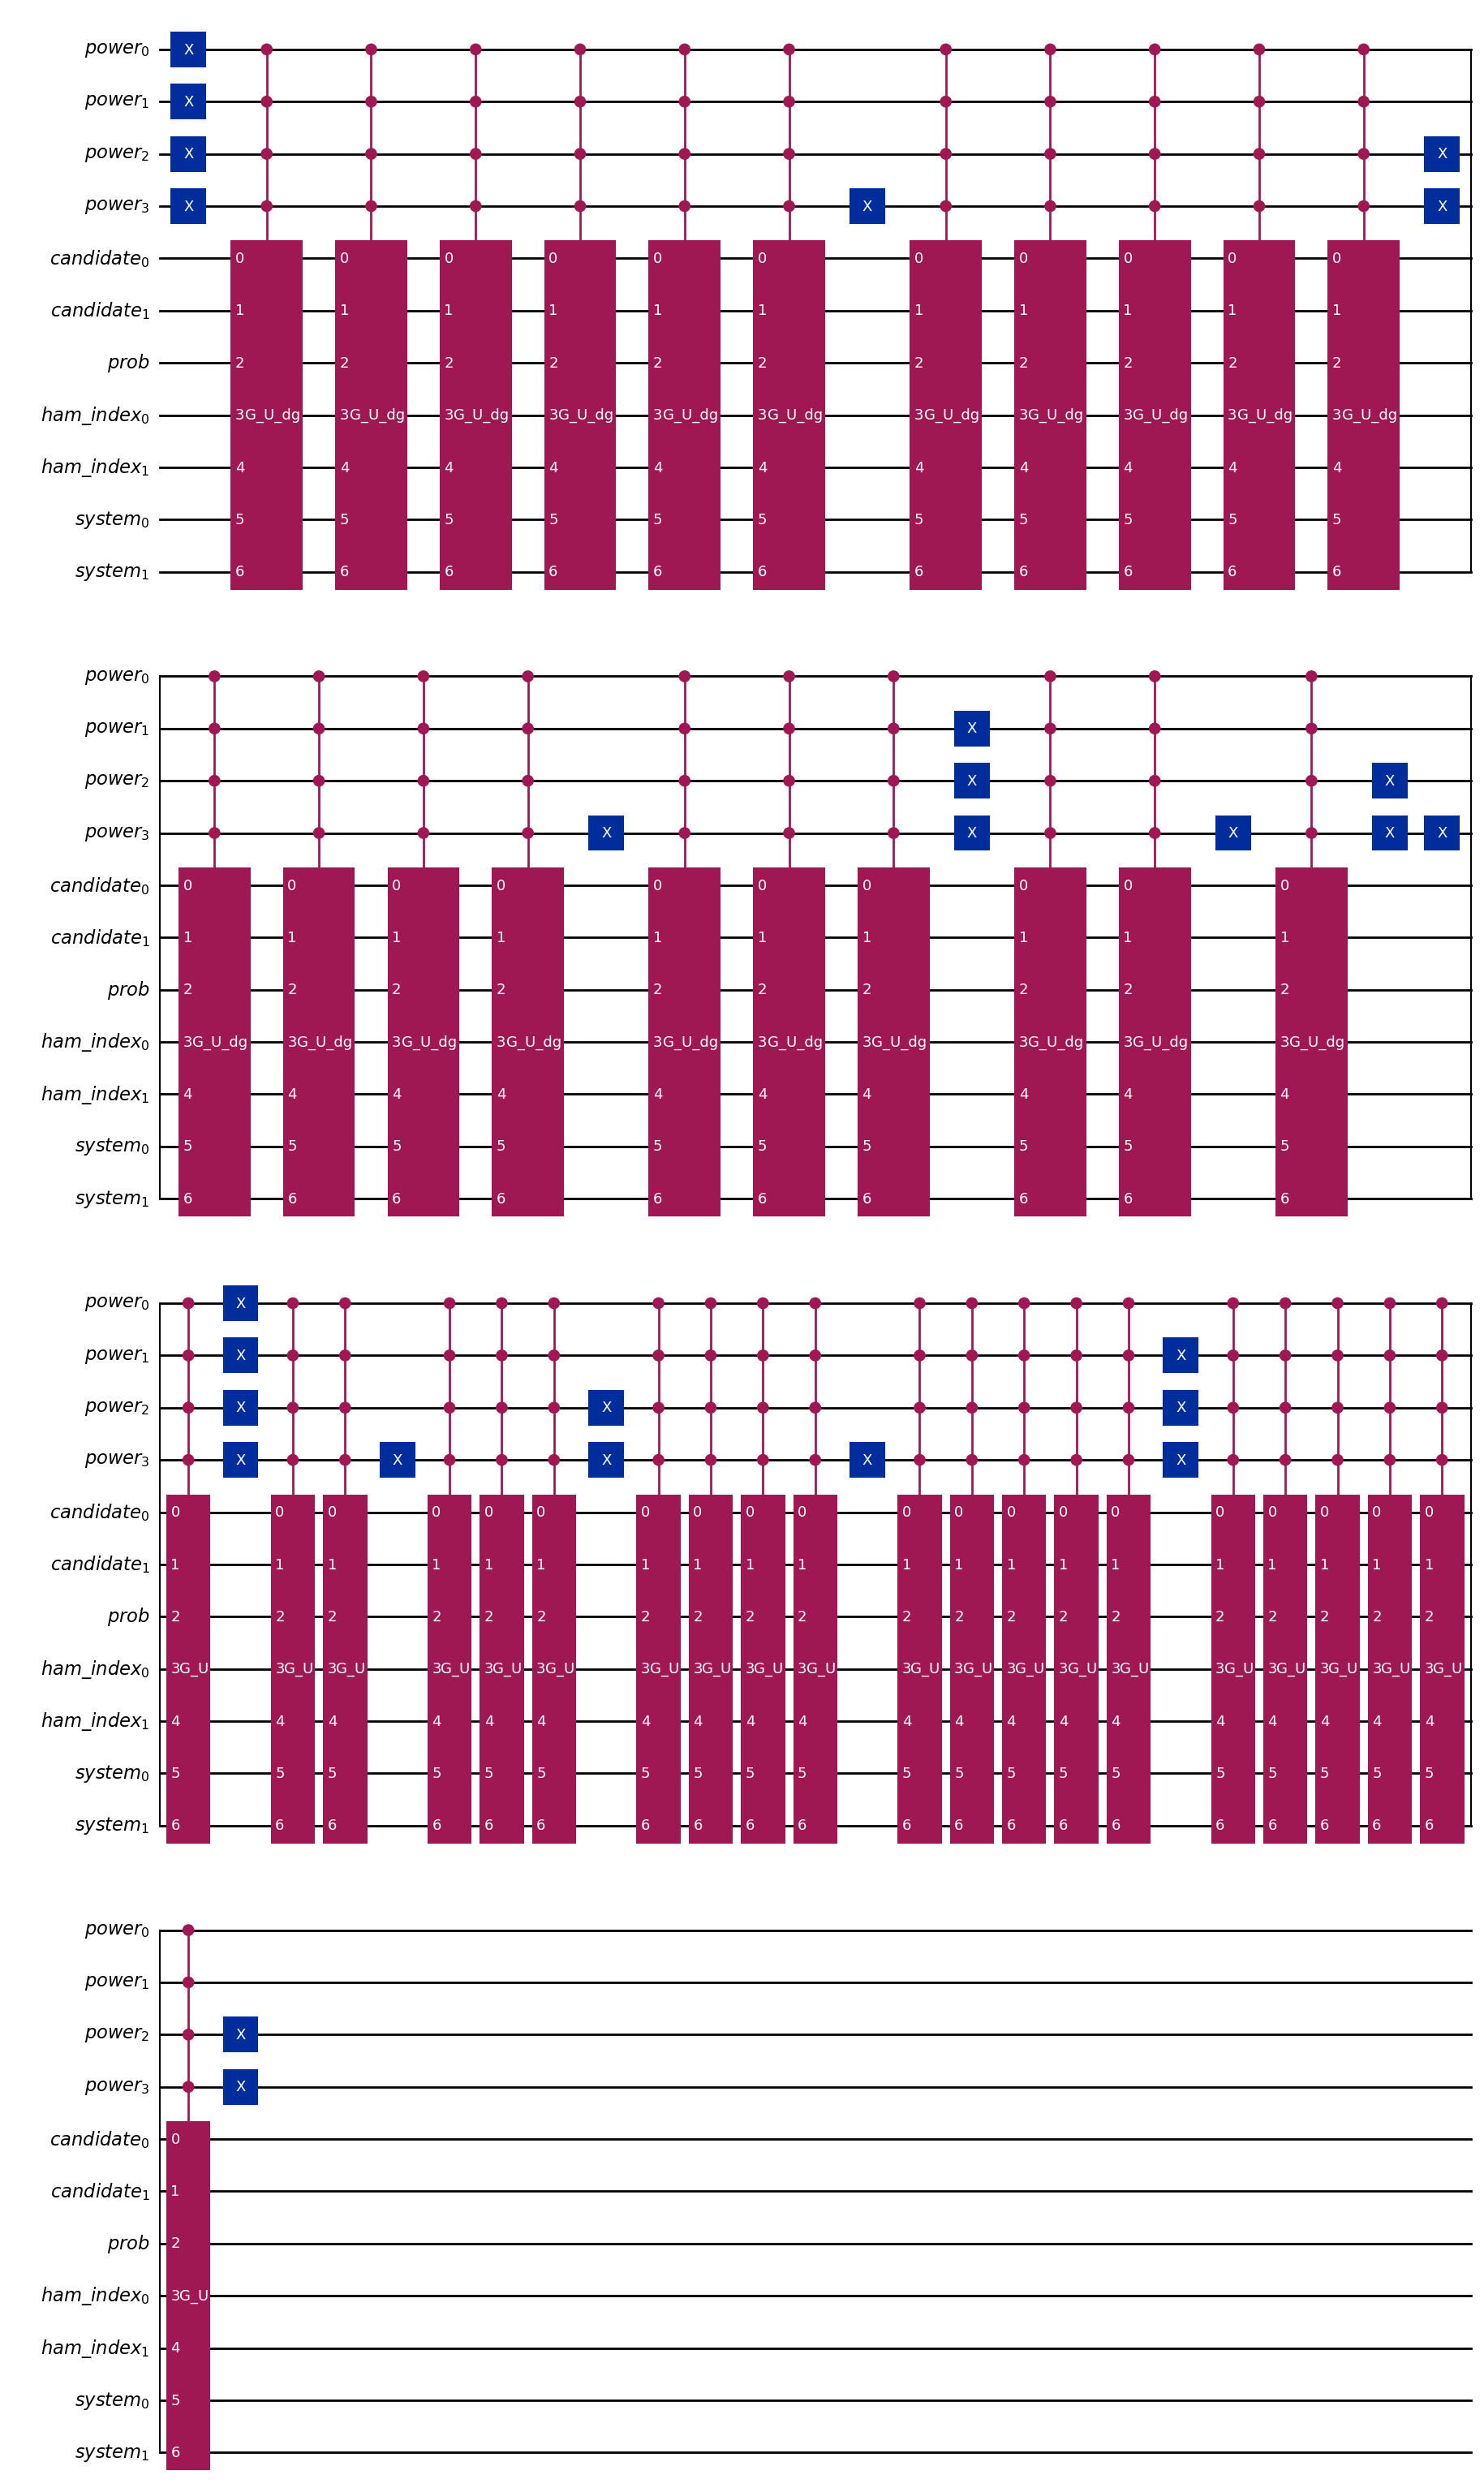

In [148]:
SELECT_G.draw("mpl")